# TMM
- data collection and preparation 

In [1]:
import pandas as pd

In [2]:
SiO2 = pd.read_csv('Malitson.csv')
Si   = pd.read_csv('Aspnes.csv')

In [3]:
print("=== Silicio ===")
print(Si.columns.tolist())
print(Si.head())

print("\n=== SiO2 ===")
print(SiO2.columns.tolist())
print(SiO2.head())

=== Silicio ===
['wl', 'n']
       wl      n
0  0.2066  1.010
1  0.2101  1.083
2  0.2138  1.133
3  0.2175  1.186
4  0.2214  1.247

=== SiO2 ===
['0.2100', '1.5383576204905;;;;']
   0.2100  1.5383576204905;;;;
0  0.2174   1.530846431063;;;;
1  0.2251  1.5240789072975;;;;
2  0.2330  1.5180417677275;;;;
3  0.2412  1.5125721155558;;;;
4  0.2497  1.5076095872199;;;;


SiO2 csv non ha la prima riga di intestazione

In [4]:
SiO2 = pd.read_csv("Malitson.csv", header=None, names=["wl", "n"])

In [5]:
print("\n=== SiO2 ===")
print(SiO2.columns.tolist())
print(SiO2.head())


=== SiO2 ===
['wl', 'n']
       wl                    n
0  0.2100  1.5383576204905;;;;
1  0.2174   1.530846431063;;;;
2  0.2251  1.5240789072975;;;;
3  0.2330  1.5180417677275;;;;
4  0.2412  1.5125721155558;;;;


In [6]:
SiO2 = SiO2.dropna(how='all', axis=1)  #how=all cancella la colonna se tutti i suoi el son NaN, axis=1 colonne, 0 righe

In [7]:
print("\n=== SiO2 ===")
print(SiO2.columns.tolist())
print(SiO2.head())


=== SiO2 ===
['wl', 'n']
       wl                    n
0  0.2100  1.5383576204905;;;;
1  0.2174   1.530846431063;;;;
2  0.2251  1.5240789072975;;;;
3  0.2330  1.5180417677275;;;;
4  0.2412  1.5125721155558;;;;


Bisognerebbe convertire in numero però non basta perchè refractive index quando genera il csv aggiunge ;;;; che non sono numeri. <br>
Usare pd.to_numeric(SiO2["n"], errors='coerce') fallisce perché diventano silenziosamente NaN e plot crasha

In [8]:
SiO2["n"] = SiO2["n"].astype(str).str.rstrip(';').astype(float)   #elimina e converte insieme
print("\n=== SiO2 ===")
print(SiO2.dtypes)

Si["n"] = pd.to_numeric(Si["n"], errors='coerce')
print("\n=== Si ===")
print(Si.dtypes)


=== SiO2 ===
wl    float64
n     float64
dtype: object

=== Si ===
wl     object
n     float64
dtype: object


In [9]:
print("\n=== SiO2 ===")
print(SiO2.columns.tolist())
print(SiO2.head())


=== SiO2 ===
['wl', 'n']
       wl         n
0  0.2100  1.538358
1  0.2174  1.530846
2  0.2251  1.524079
3  0.2330  1.518042
4  0.2412  1.512572


In [10]:
errori_SiO2 = SiO2.isna().sum()
errori_Si = Si.isna().sum()

print(errori_SiO2)
print("\n")
print(errori_Si)

wl    0
n     0
dtype: int64


wl    0
n     1
dtype: int64


In [11]:
righe_errore = Si[Si['n'].isna()]
print(righe_errore)

    wl   n
46  wl NaN


In [12]:
Si_originale = pd.read_csv('Aspnes.csv')

In [13]:
print(Si_originale.loc[46])

wl    wl
n      k
Name: 46, dtype: object


In [18]:
Si_originale = pd.read_csv('Aspnes.csv')
print(len(Si_originale))                            
print(Si_originale.loc[45])                           
print(Si_originale.loc[46])                         
print(Si_originale.loc[47])            

93
wl    0.8266
n      3.673
Name: 45, dtype: object
wl    wl
n      k
Name: 46, dtype: object
wl    0.2066
n      2.909
Name: 47, dtype: object


**NB** il sito invece che esportare tre colonne mette due tabelle una sotto l'altra

In [20]:
# la riga "fantasma" ha nella colonna wl il testo letterale "wl"
indice_secondo_header = Si_originale[Si_originale['wl'] == 'wl'].index[0]
print(indice_secondo_header)   # deve stampare 46

blocco_n = Si_originale.iloc[:indice_secondo_header].copy()
blocco_n.columns = ['wl', 'n']
blocco_n = blocco_n.astype(float)

blocco_k = Si_originale.iloc[indice_secondo_header + 1:].copy()
blocco_k.columns = ['wl', 'k']
blocco_k = blocco_k.astype(float)
blocco_k = blocco_k.reset_index(drop=True)
blocco_n = blocco_n.reset_index(drop=True)

46


verifichiamo che le wl siano le stesse per i due blocchi!

In [21]:
print((blocco_n['wl'] - blocco_k['wl']).abs().max())

0.0


In [29]:
Si = pd.DataFrame({
    'wl': blocco_n['wl'],
    'n':  blocco_n['n'],
    'k':  blocco_k['k']
})
print(Si.head())
print("\n", "length =", len(Si))   # ci aspettiamo 46

       wl      n      k
0  0.2066  1.010  2.909
1  0.2101  1.083  2.982
2  0.2138  1.133  3.045
3  0.2175  1.186  3.120
4  0.2214  1.247  3.206

 length = 46


In [30]:
print(SiO2.head())

       wl         n
0  0.2100  1.538358
1  0.2174  1.530846
2  0.2251  1.524079
3  0.2330  1.518042
4  0.2412  1.512572


ok proseguiamo adesso ordinando in modo crescente se già non lo fossero per interpolare

In [37]:
print("Si è già ordinato?", Si["wl"].is_monotonic_increasing)
print("SiO2 è già ordinato?", SiO2["wl"].is_monotonic_increasing)

#altrimenti:
Si   = Si.sort_values("wl").reset_index(drop=True)
SiO2 = SiO2.sort_values("wl").reset_index(drop=True)

Si è già ordinato? True
SiO2 è già ordinato? True


In [36]:
import matplotlib.pyplot as plt

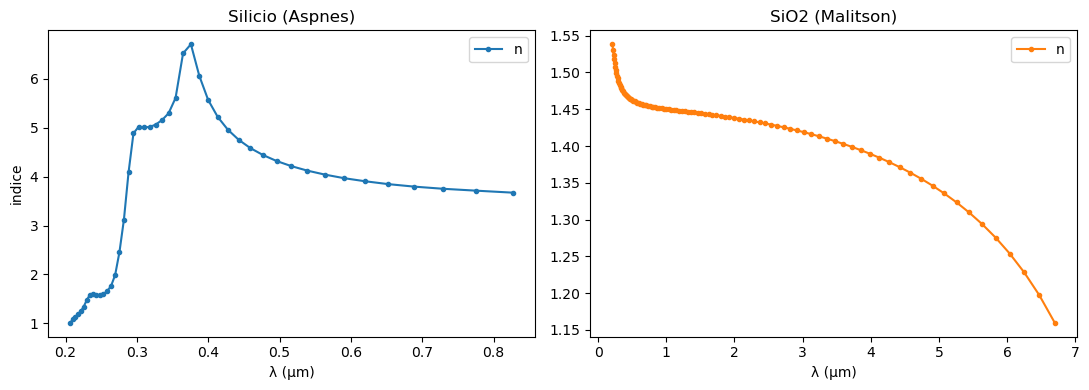

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))                  #griglia di grafici con 1 riga e 2 colonne, larga 11 e alta 4 pollici

axes[0].plot(Si["wl"], Si["n"], "o-", markersize=3, label="n")   #gli assi riferiti ad una lista array che contiene i singoli grafici
axes[0].set_xlabel("λ (µm)")
axes[0].set_ylabel("indice")
axes[0].set_title("Silicio (Aspnes)")
axes[0].legend()

axes[1].plot(SiO2["wl"], SiO2["n"], "o-", markersize=3, color="tab:orange", label="n")
axes[1].set_xlabel("λ (µm)")
axes[1].set_title("SiO2 (Malitson)")
axes[1].legend()

plt.tight_layout()
plt.show()

ok interpolazione:

In [70]:
import numpy as np
from scipy.interpolate import interp1d, CubicSpline

n_SiO2_lin = interp1d(SiO2["wl"], SiO2["n"], kind="linear")
n_Si_lin = interp1d(Si["wl"], Si["n"], kind="linear")
k_Si_lin = interp1d(Si["wl"], Si["k"], kind="linear")

def n_complesso_SiO2(wl):
    return n_SiO2_lin(wl) + 0j

n_complesso_SiO2 = lambda wl: n_SiO2_lin(wl) + 0j     # stessa notazione su una riga
n_complesso_Si   = lambda wl: n_Si_lin(wl) + 1j*k_Si_lin(wl)

- Fresnell - incidenza normale <br>
$$\displaystyle r_{i,j} = \frac{n_i - n_j}{n_i + n_j} \qquad\qquad \displaystyle t_{i,j} = \frac{2n_i}{n_i + n_j}$$

In [71]:
def fresnel_normale(n_i, n_j):
    r = (n_i - n_j) / (n_i + n_j)
    t = 2*n_i / (n_i + n_j)
    return r, t

In [72]:
wl_test = 0.55  

n_aria = 1.0
n_ossido = n_SiO2_lin(wl_test)
n_silicio = n_Si_lin(wl_test)

r_1, t_1 = fresnel_normale(n_aria, n_ossido)
r_2, t_2 = fresnel_normale(n_ossido, n_silicio)

print("interfaccia 1 (aria/SiO2):", r_1, t_1)
print("interfaccia 2 (SiO2/Si):  ", r_2, t_2)

interfaccia 1 (aria/SiO2): -0.18696445062181544 0.8130355493781846
interfaccia 2 (SiO2/Si):   -0.4736078812612292 0.5263921187387707


&rarr; lettura paper Multilayer Optical calculations S.J. Byrnes